California Housing dataset
--------------------------

**Data Set Characteristics:**

Number of Instances: 20640

Attribute Information:


*   ***MedInc***        median income in block group
*   ***HouseAge***     median house age in block group
*   ***AveRooms***      average number of rooms per household
*   ***AveBedrms***     average number of bedrooms per household
*   ***Population***    block group population
*   ***AveOccup***      average number of household members
*   ***Latitude***      block group latitude
*   ***Longitude***     block group longitude

Missing Attribute Values: None


The ***target*** variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block group is the smallest geographical unit for which the U.S.
Census Bureau publishes sample data (a block group typically has a population
of 600 to 3,000 people).

A household is a group of people residing within a home. Since the average
number of rooms and bedrooms in this dataset are provided per household, these
columns may take surprisingly large values for block groups with few households
and many empty houses, such as vacation resorts.

In [12]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


In [23]:
data = pd.read_csv('./california_housing.csv').drop(columns=['index'])
data.head(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,2.9958,37.0,3.857658,0.963964,1093.0,1.969369,37.69,-122.14,1.784
1,9.3125,27.0,6.233083,0.857143,383.0,2.879699,33.90,-117.91,2.935


In [24]:
X_train, X_test, y_train, y_test = train_test_split(data[data.columns[:-1]], data.target, test_size=0.2)
print(f"X_train: {X_train.shape[0]} y_train: {y_train.shape[0]}")
print(f"X_test: {X_test.shape[0]} y_test: {y_test.shape[0]}")

X_train: 14860 y_train: 14860
X_test: 3716 y_test: 3716


In [25]:
# Normalizar los datos (IMPORTANTE para redes neuronales)
from sklearn.preprocessing import StandardScaler

X = data[data.columns[:-1]]  # Features
y = data[data.columns[-1]]   # Target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [26]:
# Definir la arquitectura de la red neuronal
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), #Capa de entrada
    layers.Dense(64, activation='relu'), #Capa oculta
    layers.Dense(1)  # Capa de salida
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

/home/holly/Proyectos/RelacionesInterpesonalesMAC/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=20, validation_split=0.2, verbose=1)

Epoch 1/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 406.0585 - val_loss: 2.6890
Epoch 2/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7038 - val_loss: 2.0134
Epoch 3/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4538 - val_loss: 1.4426
Epoch 4/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.8728 - val_loss: 1.1421
Epoch 5/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7063 - val_loss: 1.1389
Epoch 6/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.5898 - val_loss: 1.1450
Epoch 7/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 307.9597 - val_loss: 35.7303
Epoch 8/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.9137 - val_loss: 0.9656
Epoch 9/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2020 - val_loss: 4.5268
Epoch 10/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4517 - val_loss: 0.9446
Epoch 11/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2441 - val_loss: 0.8602
Epoch 12/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3m

In [29]:
test_loss = model.evaluate(X_test, y_test, verbose=2)
print(f'Pérdida en el conjunto de prueba: {test_loss:.4f}')

117/117 - 0s - 2ms/step - loss: 4.5410
Pérdida en el conjunto de prueba: 4.5410


In [30]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,405 (56.27 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,604 (37.52 KB)

In [31]:
r2_score(model.predict(X_test).flatten(), y_test)

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


-0.8418651937444339

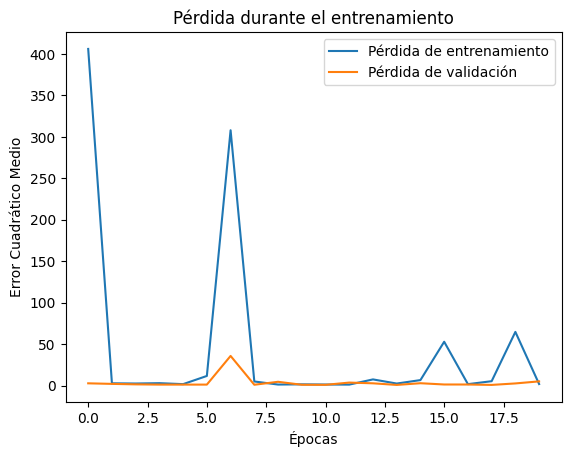

In [32]:
# Visualizar la pérdida a lo largo de las épocas
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio')
plt.legend()
plt.show()

Iris plants dataset
--------------------

**Data Set Characteristics:**

Number of Instances: 150 (50 in each of three classes)

Attribute Information:
*   sepal length in cm
*   sepal width in cm
*   petal length in cm
*   petal width in cm

class:
*   Iris-Setosa
*   Iris-Versicolour
*   Iris-Virginica



In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [ ]:
# Cargar el conjunto de datos de Iris
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encoding de las etiquetas
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
df = pd.DataFrame(data=iris.data, columns=['sepal_length','sepal_width','petal_length','petal_width'])
df['clasificacion'] = iris.target
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,clasificacion
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [ ]:
# Definir la arquitectura de la red neuronal
model = keras.Sequential([
    layers.Dense(2, activation='relu', input_shape=(X_train.shape[1],)), #capa de entrada
    layers.Dense(2, activation='relu'), #Capa intermedia
    layers.Dense(3, activation='softmax')  # Capa de salida (3 clases)
])

# Compilar el modelo
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, validation_split=0.2, verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.3620 - loss: 1.1171 - val_accuracy: 0.2083 - val_loss: 1.1622
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3620 - loss: 1.0687 - val_accuracy: 0.2083 - val_loss: 1.1181
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3750 - loss: 1.0264 - val_accuracy: 0.2083 - val_loss: 1.0821
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3997 - loss: 0.9697 - val_accuracy: 0.3750 - val_loss: 1.0283
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5443 - loss: 0.9155 - val_accuracy: 0.6667 - val_loss: 0.9682
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7448 - loss: 0.8812 - val_accuracy: 0.7083 - val_loss: 0.9361
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8060 - loss: 0.8755 - val_accuracy: 0.7917 - val_loss: 0.9153
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7995 - loss: 0.8479 - val_accuracy: 0.8333 - val_loss: 0.8986

In [ ]:
# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Pérdida en el conjunto de prueba: {test_loss:.4f}, Precisión: {test_accuracy:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8000 - loss: 0.4714
Pérdida en el conjunto de prueba: 0.4714, Precisión: 0.8000


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (112.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

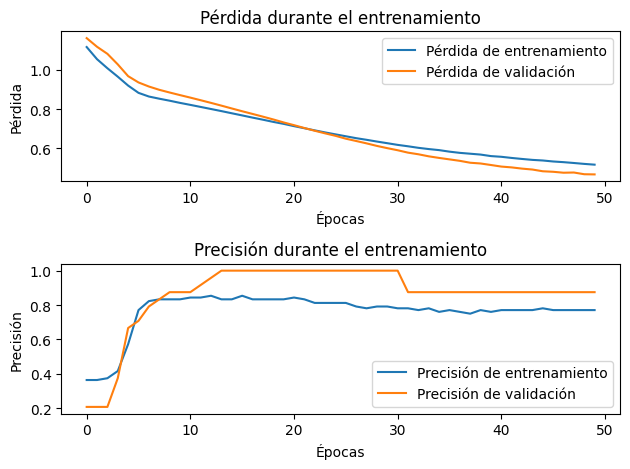

In [ ]:
# Visualizar la pérdida y la precisión a lo largo de las épocas
plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()